# Modern Tranining Techniques
## Gradient descent in two parts
Introduces to additions to the the `training_simple_model_EZA` to create an upgraded `training_model_EZA`.
The new additions are the `Optimizer` and `lr_schedule` args.
The new function is located in the `dl_utils.py` file.

### Testing the new `training_model_EZA` with the Fashion-MNIST dataset

In [65]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

In [76]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # False is better for RNNs with variable input sizes

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 dl_utils loaded
Device available: cuda


In [5]:
# Arguments
epochs = 100  # number of epochs to train
B = 512    # A respectable batch size

In [6]:
# Load the Fashion-MNIST dataset
train_fmnist_data = torchvision.datasets.FashionMNIST("./data", train=True, transform=transforms.ToTensor(), download=True)
test_fmnist_data = torchvision.datasets.FashionMNIST("./data", train=False, transform=transforms.ToTensor(), download=True)

In [57]:
# Data loaders
train_fmnist_loader = DataLoader(train_fmnist_data, 
                                 batch_size=B, 
                                 shuffle=True,
                                 num_workers=4,
                                 pin_memory=True,
                                 persistent_workers=True,
                                 drop_last=True
)

test_fmnist_loader = DataLoader(test_fmnist_data, 
                                batch_size=B*2,
                                shuffle=False,
                                num_workers=4,
                                persistent_workers=True,
                                pin_memory=True
)

In [8]:
# Fully connected network with three hidden layers

D = 28*28    # values in the input to determine the size of subsequent layers
n= 128    # Hidden layer size
C = 1    # Channels per input
classes = 10 # Number of classesin MNIST

fc_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, classes)
)

In [9]:
# Hyperparameters
eta_0 = 0.1  # Starting learning rate
loss_function = nn.CrossEntropyLoss()

In [15]:
# Run the training model
fc_results = train_network_EZA(fc_model,
                               loss_function,
                               train_fmnist_loader,
                               test_loader=test_fmnist_loader,
                               epochs=epochs,
                               device=device,
                               score_funcs={'Accuracy': accuracy_score},
                               )

Epoch: 100%|██████████| 100/100 [05:04<00:00,  3.04s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

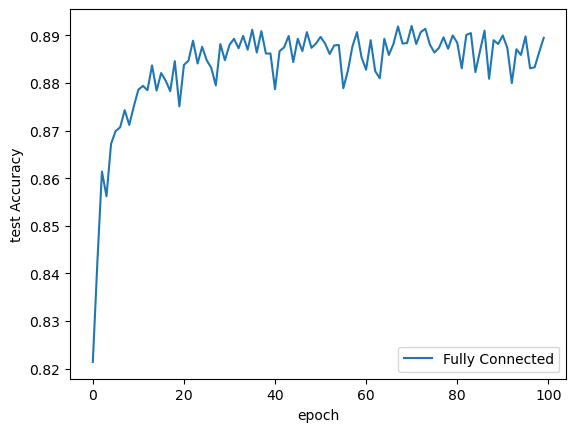

In [16]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Fully Connected')

### Learning rate schedules
The schedulers help to:
- Stabilize oscillating models
- Reduce the number of epochs needed to train
- Maximize accuracy of final model

The most important schedulers are:
1. **Exponential Decay:** Smoothing erratic training
2. **Step Drop Adjustment:** Better smoothing
3. **Cosine Annealing:** Greater accuracy but less stability
4. **Validation Plaeatu:** Data-based adjustments

Text(0, 0.5, 'Learning Rate')

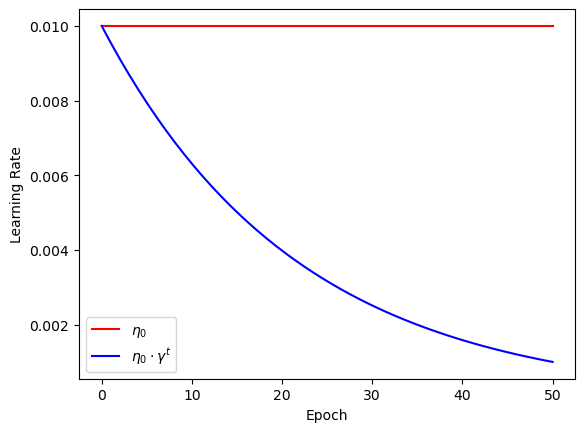

In [49]:
# Exponential decay visualization
T = 50 # epochs
epochs_input = np.linspace(0, 50, 50)  # All t values
eta_init = 0.01   # initial learning rate
eta_min = eta_init/10 # minimum rate

gamma_ex = np.power(eta_min/eta_init, 1./T) # compute the decay rate gamma

effective_learning_rate = eta_init * np.power(gamma_ex, epochs_input) # all the nt values

# Plot the exponential decay
sns.lineplot(x=epochs_input, y=eta_init, color='red', label="$\eta_0$")
ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label="$\eta_0 \cdot \gamma^t$")
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')

In [18]:
# EXPONENTIAL DECAY gamma function
def gamma_decay(eta_min, eta_init, epochs):
    gamma = (eta_min/eta_init)**(1/epochs)
    return gamma

In [19]:
# EXPONENTIAL DECAY 

# First we recreate the model
fc_model_exp_dec = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, classes)
)

eta_min = 0.01
eta_0 = 0.1

gamma = gamma_decay(eta_min, eta_0, epochs)

optimizer = torch.optim.SGD(fc_model_exp_dec.parameters(), lr=eta_0)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma)


In [20]:
fc_model_exp_dec_results = train_network_EZA(fc_model_exp_dec,
                                             loss_function,
                                             train_fmnist_loader,
                                             test_loader=test_fmnist_loader,
                                             epochs=100,
                                             optimizer=optimizer,
                                             lr_schedule=scheduler,
                                             score_funcs={'Accuracy': accuracy_score},
                                             device=device,
                                             )

Epoch: 100%|██████████| 100/100 [04:52<00:00,  2.93s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

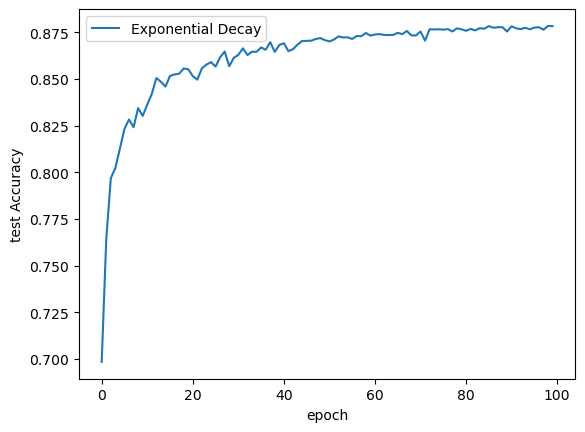

In [33]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_exp_dec_results, label='Exponential Decay')

In [38]:
# STEP DROP ADJUSTMENT

# First we recreate the model
fc_model_step = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, classes)
)

optimizer_step = torch.optim.SGD(fc_model_step.parameters(), lr=eta_0)
scheduler_step = torch.optim.lr_scheduler.StepLR(optimizer_step, epochs//4, gamma=0.3)

In [ ]:
# STEP DROP ADJUSTMENT — reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

# Run the model
fc_model_step_results = train_network_EZA(fc_model_step,
                                             loss_function,
                                             train_fmnist_loader,
                                             test_loader=test_fmnist_loader,
                                             epochs=100,
                                             optimizer=optimizer_step,
                                             lr_schedule=scheduler_step,
                                             score_funcs={'Accuracy': accuracy_score},
                                             device=device,
                                             )

Epoch: 100%|██████████| 100/100 [05:21<00:00,  3.22s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

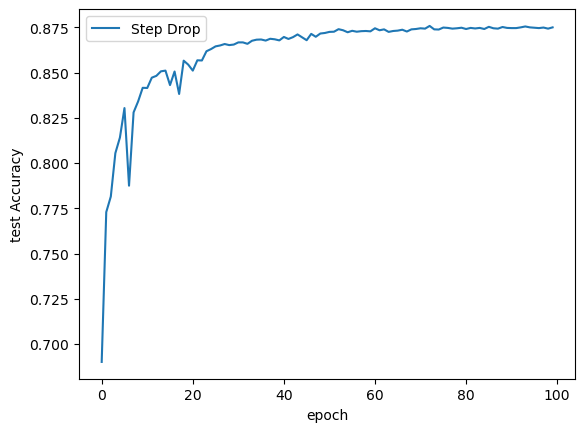

In [42]:
# Plot results of drop step model
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_step_results, label='Step Drop')

In [51]:
# COSINE ANNEALING

# Function to calculate the cos_lr
def cosine(eta_init, eta_min, epochs_input, T):
    cos_lr = eta_min + 0.5 * (eta_init-eta_min) * (1+np.cos(epochs_input/(T/3.0)*np.pi))
    return cos_lr

cos_lr = cosine(eta_init, eta_min, epochs_input, T)

Text(0, 0.5, 'Learning Rate')

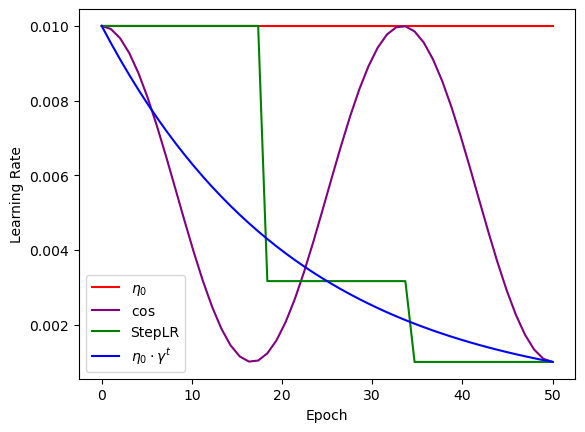

In [52]:
# Compare learning rates
sns.lineplot(x=epochs_input, y=eta_init, color='red', label="$\eta_0$")
sns.lineplot(x=epochs_input, y=cos_lr, color='purple', label="$\cos$")
sns.lineplot(x=epochs_input, y=[eta_init]*18+[eta_init/3.16]*16+[eta_init/10]*16, color='green', label="StepLR")
ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label="$\eta_0 \cdot \gamma^t$")
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')

In [53]:
# Apply cosine annealing to the model
# First we recreate the model
fc_model_cosine = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, classes)
)

optimizer_cosine = torch.optim.SGD(fc_model_cosine.parameters(), lr=eta_0)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cosine, epochs//3, eta_min=0.0001)

In [ ]:
# Train the model with cosine annealing scheduler
# STEP DROP ADJUSTMENT 
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

# Run the model
fc_model_cosine_results = train_network_EZA(fc_model_cosine,
                                             loss_function,
                                             train_fmnist_loader,
                                             test_loader=test_fmnist_loader,
                                             epochs=100,
                                             optimizer=optimizer_cosine,
                                             lr_schedule=scheduler_cosine,
                                             score_funcs={'Accuracy': accuracy_score},
                                             device=device,
                                             )

Epoch: 100%|██████████| 100/100 [05:07<00:00,  3.08s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

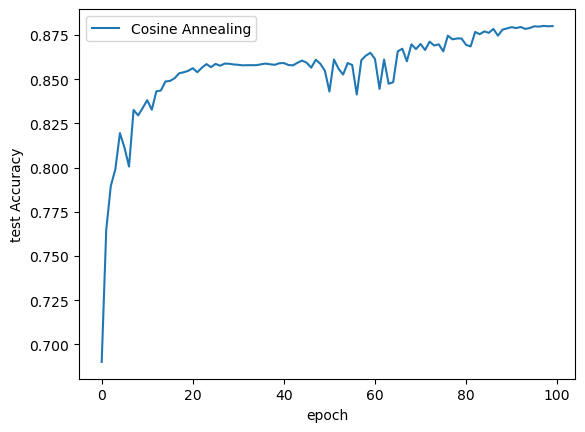

In [59]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_cosine_results, label='Cosine Annealing')

<Axes: xlabel='epoch', ylabel='test loss'>

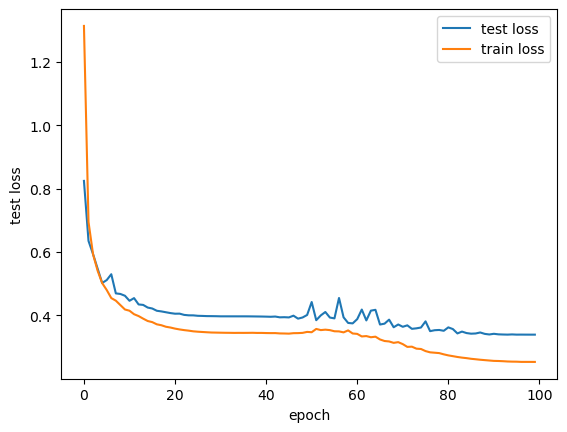

In [60]:
# VALIDATION PLATEAU

# First let's see the train and test loss of our model
sns.lineplot(x='epoch', y='test loss', data=fc_model_cosine_results, label='test loss')
sns.lineplot(x='epoch', y='train loss', data=fc_model_cosine_results, label='train loss')

In [74]:
""" 
VALIDATION PLATEAU

It has three primary arguments to control:

1. Patience: Number of epochos of no improvement to see before reducing the learning rate
2. Threshold: Defines what counts as not improving. A value ov 0.01 is 1% improvement of the loss. This should be explored
3. Factor: The value to drop from the learning rate.

We DO NOT use the test data to choose when to alter the learning rate

"""
# Set the plateau model
fc_model_plateau = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, n),
    nn.Tanh(),
    nn.Linear(n, classes)
)

# Create the training and validation subsets since we do not have explicit validation and tests sets
train_sub_set, val_sub_set = torch.utils.data.random_split(train_fmnist_data, [int(len(train_fmnist_data)*0.8),
                                                                               int(len(train_fmnist_data)*0.2)])

# Data loaders for train and validation subsets
train_sub_loader = DataLoader(train_sub_set, 
                                 batch_size=B, 
                                 shuffle=True,
                                 num_workers=4,
                                 pin_memory=True,
                                 persistent_workers=True,
                                 drop_last=True
)

val_sub_loader = DataLoader(val_sub_set, 
                                batch_size=B*2,
                                shuffle=False,
                                num_workers=4,
                                persistent_workers=True,
                                pin_memory=True
)

# Optimizer and scheduler

optimizer_plateau = torch.optim.SGD(fc_model_plateau.parameters(), lr=eta_0)
scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_plateau, 
                                                               mode='min', 
                                                               factor=0.2, 
                                                               patience=10)

In [77]:
# Train the model with validation plateau
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

# Run the model
fc_model_plateau_results = train_network_EZA(fc_model_plateau,
                                             loss_function,
                                             train_fmnist_loader,
                                             val_loader=val_sub_loader,
                                             test_loader=test_fmnist_loader,
                                             epochs=100,
                                             optimizer=optimizer_plateau,
                                             lr_schedule=scheduler_plateau,
                                             score_funcs={'Accuracy': accuracy_score},
                                             device=device,
                                             )


Epoch: 100%|██████████| 100/100 [06:04<00:00,  3.64s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

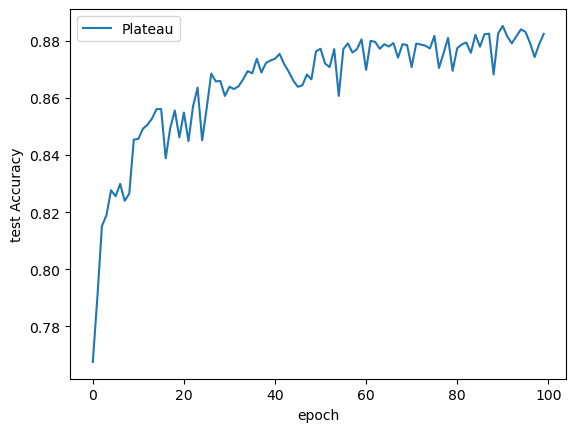

In [78]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_plateau_results, label='Plateau')

<Axes: xlabel='epoch', ylabel='test Accuracy'>

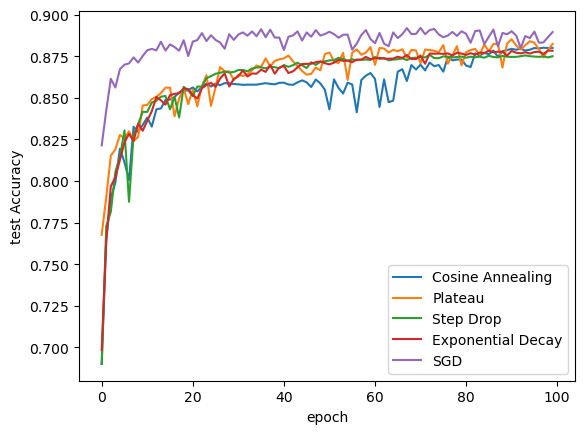

In [79]:
# Compare all the schedulers:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_cosine_results, label='Cosine Annealing')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_plateau_results, label='Plateau')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_step_results, label='Step Drop')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_exp_dec_results, label='Exponential Decay')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='SGD')